# Bottleneck & Latent Space Optimization Analysis

This notebook analyzes bottleneck architecture tweaks and latent dimensionality sweeps for the `optimized_weighted` and `grouped_latent_weighted` autoencoders. It consumes training artifacts produced under `output/Experiments/NotebookLP`.

## Notebook goals
- Inspect training metadata generated during bottleneck optimization sweeps.
- Compare best validation loss across latent dimensionalities.
- Provide quick utilities to visualize training curves for any run.

In [1]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
OUTPUT_ROOT = Path("output/Experiments/NotebookLP")
MODEL_NAMES = ["optimized_weighted", "grouped_latent_weighted"]
METADATA_PATTERN = "**/*_metadata.json"

if not OUTPUT_ROOT.exists():
    raise FileNotFoundError(
        f"Expected experiment directory {OUTPUT_ROOT} is missing. "
        "Sync or mount the experiment artifacts before running this notebook."
    )

OUTPUT_ROOT

PosixPath('output/Experiments/NotebookLP')

In [3]:
LATENT_PATTERNS = [
    re.compile(r"(?:latent[-_]?dim[-_]?|latent|ld)[-_]?(\d+)", re.IGNORECASE),
]

def infer_run_id(metadata_path: Path, model_name: str) -> str:
    relative = metadata_path.relative_to(OUTPUT_ROOT / model_name)
    parent_parts = relative.parts[:-1]
    stem = relative.stem.replace("_metadata", "")
    if parent_parts:
        return "/".join(parent_parts + (stem,))
    return stem or "root"

def extract_latent_dim(text: str):
    for pattern in LATENT_PATTERNS:
        match = pattern.search(text)
        if match:
            return int(match.group(1))
    return None

def load_metadata(metadata_path: Path) -> dict:
    with open(metadata_path, "r") as handle:
        payload = json.load(handle)
    train_losses = payload.get("train_losses", [])
    val_losses = payload.get("val_losses", [])
    best_val_loss = float(np.min(val_losses)) if len(val_losses) else np.nan
    final_train_loss = float(train_losses[-1]) if len(train_losses) else np.nan
    final_val_loss = float(val_losses[-1]) if len(val_losses) else np.nan
    best_epoch = int(np.argmin(val_losses)) + 1 if len(val_losses) else None
    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_val_loss": best_val_loss,
        "final_train_loss": final_train_loss,
        "final_val_loss": final_val_loss,
        "best_epoch": best_epoch,
        "total_epochs": len(val_losses),
        "timestamp": payload.get("timestamp"),
    }

def collect_model_runs(model_name: str) -> pd.DataFrame:
    base_dir = OUTPUT_ROOT / model_name
    if not base_dir.exists():
        print(f"[WARN] Missing {base_dir}. Skipping {model_name}.")
        return pd.DataFrame()

    metadata_files = sorted(base_dir.glob(METADATA_PATTERN))
    if not metadata_files:
        print(f"[WARN] No metadata files found under {base_dir}.")
        return pd.DataFrame()

    records = []
    for metadata_path in metadata_files:
        details = load_metadata(metadata_path)
        run_id = infer_run_id(metadata_path, model_name)
        latent_dim = extract_latent_dim(str(metadata_path)) or extract_latent_dim(run_id)
        records.append({
            "model": model_name,
            "run_id": run_id,
            "latent_dim": latent_dim,
            "metadata_path": metadata_path,
            "relative_path": metadata_path.relative_to(OUTPUT_ROOT).as_posix(),
            **details,
        })

    frame = pd.DataFrame(records)
    ordered_cols = [
        "model",
        "run_id",
        "latent_dim",
        "best_epoch",
        "best_val_loss",
        "final_val_loss",
        "final_train_loss",
        "total_epochs",
        "timestamp",
        "relative_path",
        "metadata_path",
        "train_losses",
        "val_losses",
    ]
    return frame[ordered_cols]

def collect_all_runs(model_names=None) -> pd.DataFrame:
    names = model_names or MODEL_NAMES
    frames = [collect_model_runs(name) for name in names]
    frames = [frame for frame in frames if not frame.empty]
    if not frames:
        return pd.DataFrame()
    combined = pd.concat(frames, ignore_index=True)
    numeric_cols = ["best_val_loss", "final_val_loss", "final_train_loss"]
    for col in numeric_cols:
        combined[col] = pd.to_numeric(combined[col], errors="coerce")
    return combined.sort_values(["model", "best_val_loss"])

In [5]:
run_summary = collect_all_runs()
if run_summary.empty:
    raise RuntimeError("No training metadata found for the selected models.")

display_cols = [
    "model",
    "run_id",
    "latent_dim",
    "best_epoch",
    "best_val_loss",
    "final_val_loss",
    "final_train_loss",
    "total_epochs",
    "timestamp",
    "relative_path",
]
display(run_summary[display_cols])

,model,run_id,latent_dim,best_epoch,best_val_loss,final_val_loss,final_train_loss,total_epochs,timestamp,relative_path
1,grouped_latent_weighted,grouped_latent_weighted,None,24,0.004994,0.004994,0.004899,24,2025-10-09 12:01:45,grouped_latent_weighted/grouped_latent_weighte...
0,optimized_weighted,optimized_weighted,None,106,0.002096,0.002096,0.002013,106,2025-10-09 11:47:38,optimized_weighted/optimized_weighted_metadata...


## Bottleneck architecture optimization

Review validation metrics for different bottleneck design tweaks.

/tmp/ipykernel_29018/3051803603.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="model", bbox_to_anchor=(1.02, 1), loc="upper left")


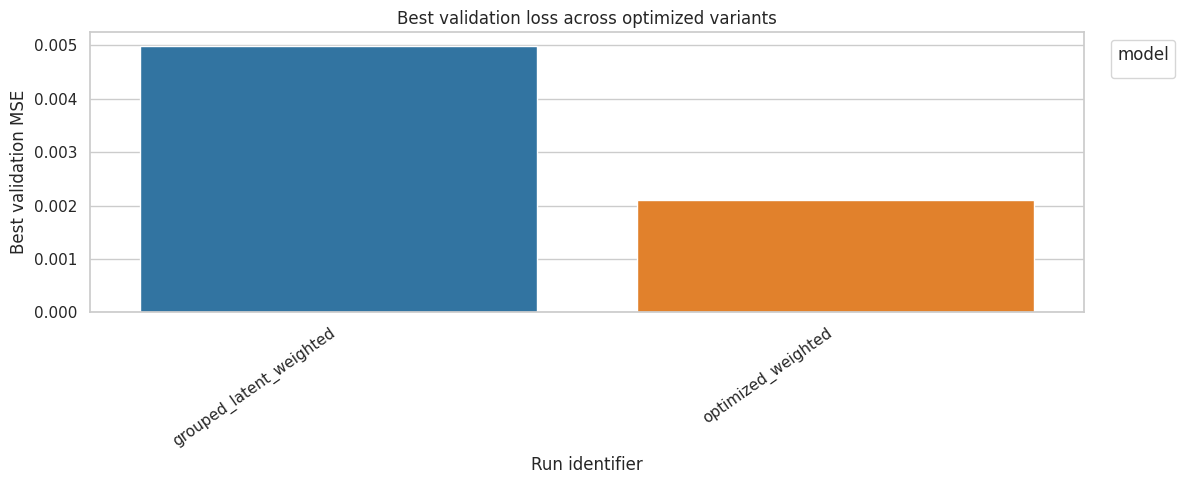

,model,run_id,latent_dim,best_epoch,best_val_loss,final_val_loss,final_train_loss,total_epochs,timestamp,relative_path
1,grouped_latent_weighted,grouped_latent_weighted,None,24,0.004994,0.004994,0.004899,24,2025-10-09 12:01:45,grouped_latent_weighted/grouped_latent_weighte...
0,optimized_weighted,optimized_weighted,None,106,0.002096,0.002096,0.002013,106,2025-10-09 11:47:38,optimized_weighted/optimized_weighted_metadata...


In [11]:
comparison_models = [
    "optimized",
    "optimized_weighted",
    "grouped_latent",
    "grouped_latent_weighted",
]

model_runs = run_summary[run_summary["model"].isin(comparison_models)].copy()

if model_runs.empty:
    print("No runs found for the selected models.")
else:
    ordered = model_runs.sort_values(["model", "best_val_loss"])

    plt.figure(figsize=(12, 5))
    sns.barplot(
        data=ordered,
        x="run_id",
        y="best_val_loss",
        hue="model",
        dodge=False,
        palette="tab10",
    )
    plt.title("Best validation loss across optimized variants")
    plt.xlabel("Run identifier")
    plt.ylabel("Best validation MSE")
    plt.xticks(rotation=35, ha="right")
    plt.legend(title="model", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    if ordered["latent_dim"].notna().any():
        plt.figure(figsize=(10, 4))
        sns.lineplot(
            data=ordered.dropna(subset=["latent_dim"]),
            x="latent_dim",
            y="best_val_loss",
            hue="model",
            marker="o",
        )
        plt.title("Best validation loss vs latent dimensionality")
        plt.xlabel("Latent dimension")
        plt.ylabel("Best validation MSE")
        plt.xscale("log", base=2)
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    display_cols = [
        "model",
        "run_id",
        "latent_dim",
        "best_epoch",
        "best_val_loss",
        "final_val_loss",
        "final_train_loss",
        "total_epochs",
        "timestamp",
        "relative_path",
    ]
    display(ordered[display_cols])